In [ ]:
# Connection to google drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

Mounted at /content/drive


Loads FAOSTAT data, filters World, "Spices, Other", Food supply (kg/capita/yr), sorts by year, and plots a clean time-series.

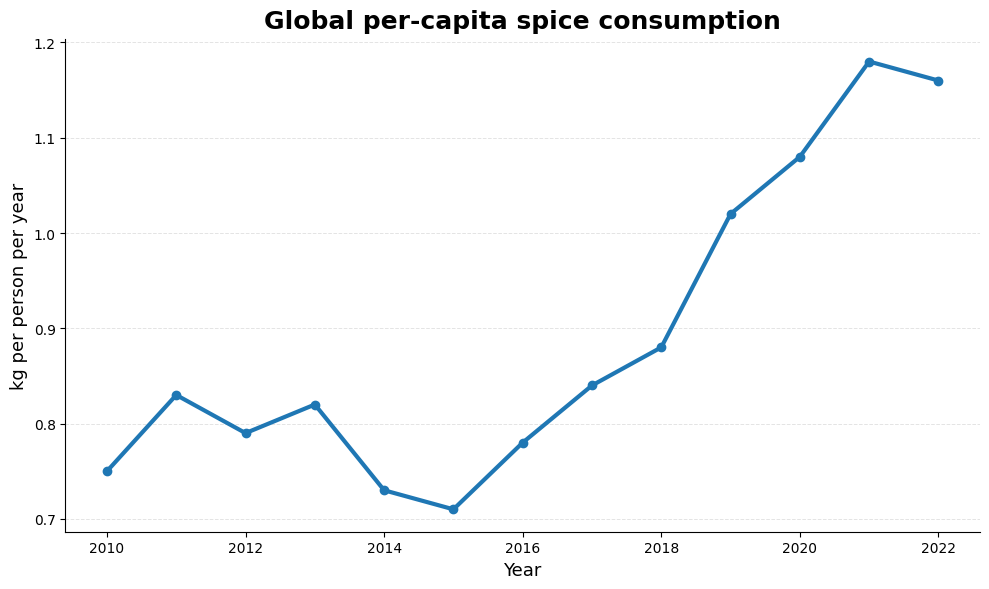

In [ ]:
# Load the dataset from FAO
FILENAME = "/content/drive/MyDrive/Data Mining - Final Project/visualization 1 - Time Series/FAOSTAT_data_en_8-14-2025.csv"
df = pd.read_csv(FILENAME)

# Filter for the item 'Spices, Other' and element 'Food supply quantity'
df = df[(df["Item"]=="Spices, Other") &
        (df["Element"]=="Food supply quantity (kg/capita/yr)") &
        (df["Area"]=="World")][["Year","Value"]].dropna().sort_values("Year") # Sort by year
years, vals = df["Year"].to_numpy(), df["Value"].to_numpy()

# plot the time series
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(years, vals, marker="o", markersize=6, linewidth=3, color="#1F77B4")
ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.35)
for s in ("top","right"): ax.spines[s].set_visible(False)

ax.set_title("Global per-capita spice consumption", fontsize=18, fontweight="bold", pad=8)
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("kg per person per year", fontsize=13)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, prune="both"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1f}"))

fig.tight_layout()
fig.savefig("spice_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()